In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim
from skimage.restoration import richardson_lucy
import time

In [2]:
from google.colab import files
uploaded = files.upload()

Saving gambar1.jpg to gambar1.jpg


(np.float64(-0.5), np.float64(7999.5), np.float64(4499.5), np.float64(-0.5))

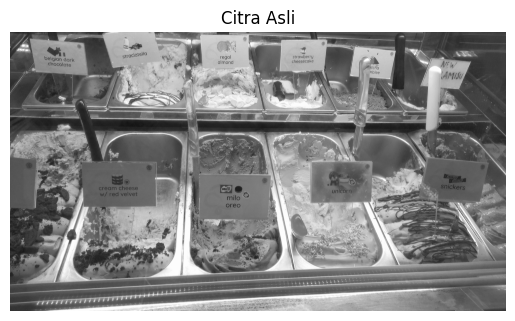

In [8]:
from skimage import io, img_as_float
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = io.imread('gambar1.jpg', as_gray=True)
image = img_as_float(image)

plt.imshow(image, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

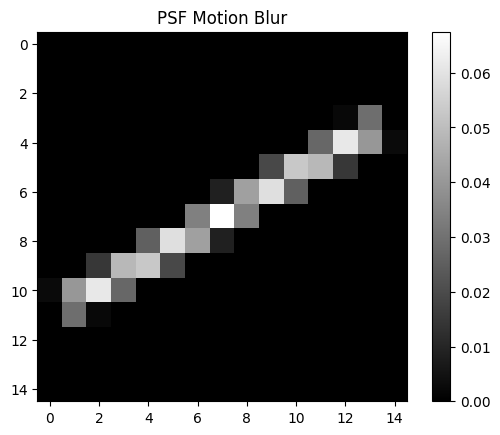

In [9]:
def motion_psf(length, angle):
    psf = np.zeros((length, length))
    center = length // 2

    for i in range(length):
        psf[center, i] = 1

    M = cv2.getRotationMatrix2D((center, center), angle, 1)
    psf = cv2.warpAffine(psf, M, (length, length))

    psf = psf / psf.sum()
    return psf

psf = motion_psf(15, 30)

plt.imshow(psf, cmap='gray')
plt.title("PSF Motion Blur")
plt.colorbar()

In [10]:
blur = cv2.filter2D(image, -1, psf)

In [11]:
gaussian_noise = blur + np.random.normal(0, 20/255, blur.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 1)

In [12]:
sp_noise = blur.copy()

prob = 0.05
rand = np.random.rand(*blur.shape)

sp_noise[rand < prob/2] = 0
sp_noise[rand > 1 - prob/2] = 1

In [13]:
def inverse_filter(img, psf):

    eps = 1e-3

    img_fft = np.fft.fft2(img)
    psf_fft = np.fft.fft2(psf, s=img.shape)

    result_fft = img_fft / (psf_fft + eps)

    result = np.abs(np.fft.ifft2(result_fft))
    return result

In [14]:
def wiener_filter(img, psf, K=0.01):

    img_fft = np.fft.fft2(img)
    psf_fft = np.fft.fft2(psf, s=img.shape)
    psf_conj = np.conj(psf_fft)

    result_fft = (psf_conj / (np.abs(psf_fft)**2 + K)) * img_fft

    result = np.abs(np.fft.ifft2(result_fft))
    return result

In [15]:
def lucy_richardson(img, psf):

    result = richardson_lucy(img, psf, num_iter=20)

    return result

In [17]:
images = {
    "motion_blur": blur,
    "gaussian_motion": gaussian_noise,
    "sp_motion": sp_noise
}

results = {}

for name, img in images.items():

    start = time.time()
    inv = inverse_filter(img, psf)
    t1 = time.time() - start

    start = time.time()
    wie = wiener_filter(img, psf, 0.01)
    t2 = time.time() - start

    start = time.time()
    lucy = lucy_richardson(img, psf)
    t3 = time.time() - start

    results[name] = {
        "inverse": (inv, t1),
        "wiener": (wie, t2),
        "lucy": (lucy, t3)
    }

In [21]:
import pandas as pd

rows = []

for scenario in results:

    for method in results[scenario]:

        img, t = results[scenario][method]

        rows.append({
            "Scenario": scenario,
            "Method": method,
            "PSNR": psnr(image, img, data_range=1),
            "MSE": mse(image, img),
            "SSIM": ssim(image, img, data_range=1),
            "Time": t
        })

df = pd.DataFrame(rows)
df

,Scenario,Method,PSNR,MSE,SSIM,Time
0,motion_blur,inverse,6.291286,0.234894,1.146617e-02,6.337484
1,motion_blur,wiener,21.987021,0.006328,6.832491e-01,5.713093
2,motion_blur,lucy,29.587532,0.001100,9.211283e-01,117.712820
3,gaussian_motion,inverse,-27.317512,539.201659,2.753728e-07,5.897972
4,gaussian_motion,wiener,11.475934,0.071188,1.503251e-02,5.550742
5,gaussian_motion,lucy,18.841853,0.013056,1.307239e-01,125.319281
6,sp_motion,inverse,-29.658549,924.389363,8.419407e-08,6.257133
7,sp_motion,wiener,8.580457,0.138661,8.746709e-03,6.215091
8,sp_motion,lucy,15.880152,0.025822,7.899360e-02,120.018905


Text(0.5, 1.0, 'Lucy-Richardson')

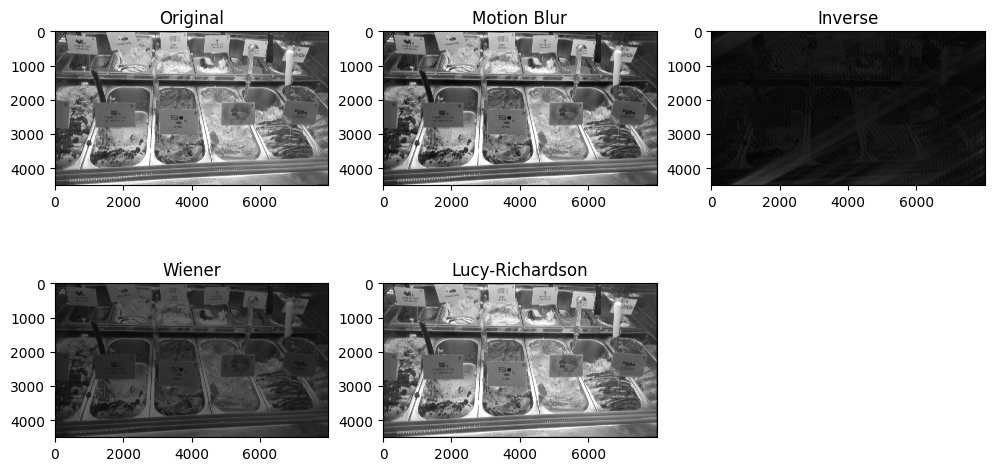

In [22]:
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Motion Blur")

plt.subplot(2,3,3)
plt.imshow(results["motion_blur"]["inverse"][0], cmap='gray')
plt.title("Inverse")

plt.subplot(2,3,4)
plt.imshow(results["motion_blur"]["wiener"][0], cmap='gray')
plt.title("Wiener")

plt.subplot(2,3,5)
plt.imshow(results["motion_blur"]["lucy"][0], cmap='gray')
plt.title("Lucy-Richardson")

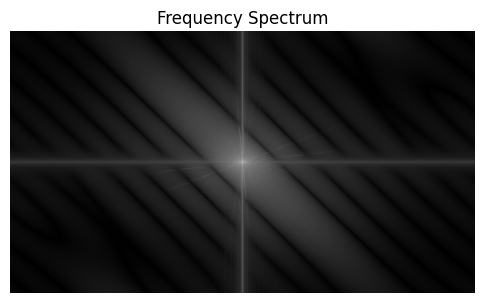

In [23]:
def show_fft(img):

    fft = np.fft.fftshift(np.fft.fft2(img))
    magnitude = np.log(np.abs(fft)+1)

    plt.imshow(magnitude, cmap='gray')
    plt.title("Frequency Spectrum")
    plt.axis('off')

plt.figure(figsize=(6,6))
show_fft(blur)